## Installation of Packages

In [18]:
#Import all required libraries

import os
import json
import math
import random
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import tensorflow as tf

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
plt.rcParams["figure.figsize"] = (10, 5)

## Reproducibility and Folders

In [5]:
# Set reproducibility controls and create the main output folder

def set_global_seed(seed: int = 42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_global_seed(42)

ROOT_OUTPUT = Path("outputs_clean_rebuild")
ROOT_OUTPUT.mkdir(parents=True, exist_ok=True)

## Main Configurations

In [8]:
# Define the main experiment configuration

BASE_CONFIG = {
    "ticker": "AAPL",
    "start": "2010-01-01",
    "end": None,
    "train_ratio": 0.70,
    "val_ratio": 0.15,
    "lookback": 40,
    "horizon": 3,
    "epochs": 20,
    "batch_size": 32,
    "lstm_units": 16,
    "dense_units": 8,
    "dropout": 0.35,
    "lr": 3e-4,
    "l2_reg": 1e-4,
    "seed": 42,
    "up_threshold": 0.01,
    "down_threshold": -0.01,
    "cost_bps": 5,
}

## Helpers Functions (Generic)

In [20]:
# Define generic helper functions for saving files and plotting

def save_json(obj, path):
    # Save a Python object as a JSON file for later reference
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=str)


def ensure_dir(path):
    # Create the folder if it does not already exist
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


def plot_training_history(history, title="Training history"):
    # Convert the Keras history object into a DataFrame for plotting
    hist = pd.DataFrame(history.history)
    hist.plot()
    plt.title(title)
    plt.grid(True)
    plt.show()

## Data Download and Feature Engineering helpers (Stocks Specific)

In [22]:
# Download stock data and create input features

def fetch_ohlcv(ticker: str, start: str = "2010-01-01", end=None) -> pd.DataFrame:
    # Download historical stock data from Yahoo Finance
    df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
    if df.empty:
        raise ValueError(f"No data returned for {ticker}.")
    # Flatten the column names if Yahoo Finance returns a multi-level format
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [c[0] for c in df.columns]
    # Keep only the standard OHLCV fields used in this project
    df = df[["Open", "High", "Low", "Close", "Volume"]].copy()
    df = df.dropna()
    return df


def add_basic_features(df: pd.DataFrame) -> pd.DataFrame:
    # Create simple price, return, moving average, and volatility features
    out = df.copy()

    out["Return_1d"] = out["Close"].pct_change()
    out["LogRet_1d"] = np.log(out["Close"] / out["Close"].shift(1))

    out["HL_Spread"] = (out["High"] - out["Low"]) / out["Close"]
    out["OC_Spread"] = (out["Close"] - out["Open"]) / out["Open"]

    out["MA5"] = out["Close"].rolling(5).mean()
    out["MA10"] = out["Close"].rolling(10).mean()
    out["MA20"] = out["Close"].rolling(20).mean()

    out["EMA10"] = out["Close"].ewm(span=10, adjust=False).mean()
    out["EMA20"] = out["Close"].ewm(span=20, adjust=False).mean()

    out["Price_to_MA5"] = out["Close"] / out["MA5"]
    out["Price_to_MA10"] = out["Close"] / out["MA10"]
    out["Price_to_MA20"] = out["Close"] / out["MA20"]

    out["Volatility_5"] = out["Return_1d"].rolling(5).std()
    out["Volatility_10"] = out["Return_1d"].rolling(10).std()
    out["Volatility_20"] = out["Return_1d"].rolling(20).std()

    out["Volume_Change"] = out["Volume"].pct_change()
    out["Volume_MA10"] = out["Volume"].rolling(10).mean()
    out["Volume_to_MA10"] = out["Volume"] / out["Volume_MA10"]

    return out


def add_technical_features(df: pd.DataFrame) -> pd.DataFrame:
    # Create additional technical indicators such as RSI, MACD, ATR, and Bollinger width
    out = df.copy()

    # Compute price changes first for RSI calculation
    delta = out["Close"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    out["RSI14"] = 100 - (100 / (1 + rs))

    ema12 = out["Close"].ewm(span=12, adjust=False).mean()
    ema26 = out["Close"].ewm(span=26, adjust=False).mean()
    out["MACD"] = ema12 - ema26
    out["MACDsig"] = out["MACD"].ewm(span=9, adjust=False).mean()
    out["MACDhist"] = out["MACD"] - out["MACDsig"]

    bb_mid = out["Close"].rolling(20).mean()
    bb_std = out["Close"].rolling(20).std()
    bb_upper = bb_mid + 2 * bb_std
    bb_lower = bb_mid - 2 * bb_std
    out["BB_Width"] = (bb_upper - bb_lower) / bb_mid

    tr1 = out["High"] - out["Low"]
    tr2 = (out["High"] - out["Close"].shift(1)).abs()
    tr3 = (out["Low"] - out["Close"].shift(1)).abs()
    out["TR"] = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    out["ATR14"] = out["TR"].rolling(14).mean()

    out["EMA_Cross"] = (out["EMA10"] > out["EMA20"]).astype(float)

    return out


def make_feature_set(df: pd.DataFrame, use_technicals: bool = False) -> pd.DataFrame:
    # Build the final feature table based on whether technical indicators are included
    out = add_basic_features(df)
    if use_technicals:
        out = add_technical_features(out)
    return out.dropna().copy()

## Target Construction Helpers

In [25]:
# Construct different prediction targets for classification and regression

def build_binary_target(df: pd.DataFrame, horizon: int = 1) -> pd.DataFrame:
    # Create a simple up or down classification target
    out = df.copy()
    # Shift the close price forward to represent the future outcome
    out["future_close"] = out["Close"].shift(-horizon)
    out["future_return"] = (out["future_close"] / out["Close"]) - 1
    out["target"] = (out["future_return"] > 0).astype(int)
    return out.dropna().copy()


def build_clean_binary_target(
    df: pd.DataFrame,
    horizon: int = 3,
    up_threshold: float = 0.01,
    down_threshold: float = -0.01,
) -> pd.DataFrame:
    out = df.copy()
    # Shift the close price forward to represent the future outcome
    out["future_close"] = out["Close"].shift(-horizon)
    out["future_return"] = (out["future_close"] / out["Close"]) - 1

    # Keep only stronger positive or negative moves outside the neutral zone
    keep_mask = (out["future_return"] >= up_threshold) | (out["future_return"] <= down_threshold)
    out = out.loc[keep_mask].copy()
    out["target"] = (out["future_return"] > 0).astype(int)

    return out.dropna().copy()


def build_regression_target(df: pd.DataFrame, horizon: int = 3) -> pd.DataFrame:
    # Create a continuous future return target for regression
    out = df.copy()
    # Shift the close price forward to represent the future outcome
    out["future_close"] = out["Close"].shift(-horizon)
    out["target"] = (out["future_close"] / out["Close"]) - 1
    return out.dropna().copy()

## Split, Scaling and Sequence Helpers

In [28]:
# Split data, scale features, and convert rows into LSTM sequences

def time_split(df: pd.DataFrame, train_ratio: float = 0.70, val_ratio: float = 0.15):
    # Split the dataset in time order into train, validation, and test sets
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()

    return train_df, val_df, test_df


def split_X_y(df: pd.DataFrame, feature_cols: list, target_col: str = "target"):
    # Separate the input features from the prediction target
    X = df[feature_cols].copy()
    y = df[target_col].copy()
    return X, y


def fit_scale_features(X_train, X_val, X_test):
    # Fit the scaler only on training data, then transform validation and test data
    scaler = RobustScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)
    return X_train_s, X_val_s, X_test_s, scaler


def fit_scale_target(y_train, y_val, y_test):
    # Scale the regression target using training data only
    scaler = RobustScaler()
    y_train_s = scaler.fit_transform(np.asarray(y_train).reshape(-1, 1)).ravel()
    y_val_s = scaler.transform(np.asarray(y_val).reshape(-1, 1)).ravel()
    y_test_s = scaler.transform(np.asarray(y_test).reshape(-1, 1)).ravel()
    return y_train_s, y_val_s, y_test_s, scaler


def make_sequences(X, y, lookback: int, dates=None):
    # Convert tabular rows into rolling time-window sequences for the LSTM
    X_seq, y_seq, idx = [], [], []
    # Each sample uses the previous lookback rows to predict the current target row
    for i in range(lookback, len(X)):
        X_seq.append(X[i - lookback:i])
        y_seq.append(y[i])
        idx.append(i)

    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)

    if dates is None:
        return X_seq, y_seq, np.array(idx)

    dates = np.array(dates)
    return X_seq, y_seq, dates[idx]

## Model Builders

In [31]:
# Build LSTM models for classification and regression

def build_lstm_classifier(input_shape, lstm_units=16, dense_units=8, dropout=0.35, lr=3e-4, l2_reg=1e-4):
    # Build an LSTM classification model that outputs an up or down probability
    inp = Input(shape=input_shape)
    x = LSTM(lstm_units, kernel_regularizer=l2(l2_reg))(inp)
    x = Dropout(dropout)(x)
    x = Dense(dense_units, activation="relu", kernel_regularizer=l2(l2_reg))(x)
    out = Dense(1, activation="sigmoid")(x)

    model = Model(inp, out)
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


def build_lstm_regressor(input_shape, lstm_units=16, dense_units=8, dropout=0.35, lr=3e-4, l2_reg=1e-4):
    # Build an LSTM regression model that outputs a future return estimate
    inp = Input(shape=input_shape)
    x = LSTM(lstm_units, kernel_regularizer=l2(l2_reg))(inp)
    x = Dropout(dropout)(x)
    x = Dense(dense_units, activation="relu", kernel_regularizer=l2(l2_reg))(x)
    out = Dense(1, activation="linear")(x)

    model = Model(inp, out)
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"],
    )
    return model

## Training Helpers

In [34]:
# Train the model with callbacks and optional class weighting

def make_class_weights(y):
    # Compute class weights to reduce the effect of class imbalance
    classes = np.unique(y)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    return {int(c): float(w) for c, w in zip(classes, weights)}


def train_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    out_dir,
    epochs=20,
    batch_size=32,
    use_class_weight=False,
):
    # Create the output folder and define where the best model will be saved
    out_dir = ensure_dir(out_dir)
    ckpt_path = out_dir / "best_model.keras"

    # Use callbacks to stop early, reduce learning rate, and save the best model
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4),
        ModelCheckpoint(filepath=str(ckpt_path), monitor="val_loss", save_best_only=True),
    ]

    fit_kwargs = {}
    if use_class_weight:
        fit_kwargs["class_weight"] = make_class_weights(y_train)

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
        callbacks=callbacks,
        **fit_kwargs,
    )

    model.save(out_dir / "final_model.keras")
    pd.DataFrame(history.history).to_csv(out_dir / "history.csv", index=False)

    return model, history

## Evaluation Helpers

In [37]:
# Evaluate classification and regression predictions

def classification_metrics(y_true, y_prob, threshold=0.5):
    # Convert probabilities into class predictions using the chosen threshold
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "auc": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else np.nan,
        "threshold": float(threshold),
    }
    return metrics, y_pred


def regression_metrics(y_true, y_pred):
    # Summarize regression performance with RMSE, MAE, and R-squared
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    return {
        "rmse": float(rmse),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }


def find_best_threshold(y_true, y_prob, thresholds=None, objective="balanced_accuracy"):
    # Search across thresholds to find the one that works best on validation data
    if thresholds is None:
        thresholds = np.arange(0.40, 0.61, 0.01)

    rows = []
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        rows.append({
            "threshold": float(thr),
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
            "precision": float(precision_score(y_true, y_pred, zero_division=0)),
            "recall": float(recall_score(y_true, y_pred, zero_division=0)),
            "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        })

    df = pd.DataFrame(rows).sort_values(objective, ascending=False).reset_index(drop=True)
    best_threshold = float(df.loc[0, "threshold"])
    return df, best_threshold

## Classification Stage Runner

In [40]:
# Run a full classification stage from data preparation to saved outputs

def run_classification_stage(
    stage_name: str,
    config: dict,
    use_technicals: bool,
    clean_target: bool,
    tune_threshold_on_val: bool = True,
):
    # Reset randomness and create an output folder for this stage
    # Reset randomness and create an output folder for this regression stage
    set_global_seed(config["seed"])
    out_dir = ensure_dir(ROOT_OUTPUT / stage_name)

    # Download raw data and build the chosen feature set
    raw = fetch_ohlcv(config["ticker"], config["start"], config["end"])
    feat = make_feature_set(raw, use_technicals=use_technicals)

    if clean_target:
        data = build_clean_binary_target(
            feat,
            horizon=config["horizon"],
            up_threshold=config["up_threshold"],
            down_threshold=config["down_threshold"],
        )
    else:
        data = build_binary_target(feat, horizon=config["horizon"])

    # Keep only the model input columns and exclude helper target columns
    feature_cols = [c for c in data.columns if c not in ["future_close", "future_return", "target"]]

    train_df, val_df, test_df = time_split(
        data,
        train_ratio=config["train_ratio"],
        val_ratio=config["val_ratio"],
    )

    X_train_df, y_train = split_X_y(train_df, feature_cols)
    X_val_df, y_val = split_X_y(val_df, feature_cols)
    X_test_df, y_test = split_X_y(test_df, feature_cols)

    X_train_s, X_val_s, X_test_s, scaler_X = fit_scale_features(X_train_df, X_val_df, X_test_df)

    X_train_seq, y_train_seq, train_dates = make_sequences(X_train_s, y_train.values, config["lookback"], train_df.index)
    X_val_seq, y_val_seq, val_dates = make_sequences(X_val_s, y_val.values, config["lookback"], val_df.index)
    X_test_seq, y_test_seq, test_dates = make_sequences(X_test_s, y_test.values, config["lookback"], test_df.index)

    # Build and train the LSTM classifier for this stage
    model = build_lstm_classifier(
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]),
        lstm_units=config["lstm_units"],
        dense_units=config["dense_units"],
        dropout=config["dropout"],
        lr=config["lr"],
        l2_reg=config["l2_reg"],
    )

    model, history = train_model(
        model=model,
        X_train=X_train_seq,
        y_train=y_train_seq,
        X_val=X_val_seq,
        y_val=y_val_seq,
        out_dir=out_dir,
        epochs=config["epochs"],
        batch_size=config["batch_size"],
        use_class_weight=True,
    )

    # Generate validation and test probabilities from the trained model
    val_prob = model.predict(X_val_seq, verbose=0).ravel()
    test_prob = model.predict(X_test_seq, verbose=0).ravel()

    best_threshold = 0.50
    threshold_table = None
    if tune_threshold_on_val:
        threshold_table, best_threshold = find_best_threshold(y_val_seq, val_prob, objective="balanced_accuracy")
        threshold_table.to_csv(out_dir / "validation_threshold_scan.csv", index=False)

    val_metrics, val_pred = classification_metrics(y_val_seq, val_prob, threshold=best_threshold)
    test_metrics, test_pred = classification_metrics(y_test_seq, test_prob, threshold=best_threshold)

    val_pred_df = pd.DataFrame({
        "date": pd.to_datetime(val_dates),
        "y_true": y_val_seq,
        "y_prob": val_prob,
        "y_pred": val_pred,
    })
    test_pred_df = pd.DataFrame({
        "date": pd.to_datetime(test_dates),
        "y_true": y_test_seq,
        "y_prob": test_prob,
        "y_pred": test_pred,
    })

    val_pred_df.to_csv(out_dir / "val_predictions.csv", index=False)
    test_pred_df.to_csv(out_dir / "test_predictions.csv", index=False)
    joblib.dump(scaler_X, out_dir / "scaler_X.pkl")
    save_json(config, out_dir / "config.json")
    save_json({"feature_cols": feature_cols}, out_dir / "features.json")
    save_json({"val_metrics": val_metrics, "test_metrics": test_metrics}, out_dir / "metrics.json")

    return {
        "stage_name": stage_name,
        "config": config,
        "model": model,
        "history": history,
        "feature_cols": feature_cols,
        "data": data,
        "threshold": best_threshold,
        "threshold_table": threshold_table,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "val_predictions": val_pred_df,
        "test_predictions": test_pred_df,
        "out_dir": out_dir,
    }

## Regression Stage Runner

In [44]:
# Run a full regression stage from data preparation to saved outputs

def run_regression_stage(
    stage_name: str,
    config: dict,
    use_technicals: bool = True,
):
    # Reset randomness and create an output folder for this stage
    # Reset randomness and create an output folder for this regression stage
    set_global_seed(config["seed"])
    out_dir = ensure_dir(ROOT_OUTPUT / stage_name)

    # Download raw data and build the chosen feature set
    raw = fetch_ohlcv(config["ticker"], config["start"], config["end"])
    # Build the feature table and create the regression target
    feat = make_feature_set(raw, use_technicals=use_technicals)
    data = build_regression_target(feat, horizon=config["horizon"])

    feature_cols = [c for c in data.columns if c not in ["future_close", "target"]]

    train_df, val_df, test_df = time_split(
        data,
        train_ratio=config["train_ratio"],
        val_ratio=config["val_ratio"],
    )

    X_train_df, y_train = split_X_y(train_df, feature_cols)
    X_val_df, y_val = split_X_y(val_df, feature_cols)
    X_test_df, y_test = split_X_y(test_df, feature_cols)

    X_train_s, X_val_s, X_test_s, scaler_X = fit_scale_features(X_train_df, X_val_df, X_test_df)
    y_train_s, y_val_s, y_test_s, scaler_y = fit_scale_target(y_train, y_val, y_test)

    X_train_seq, y_train_seq, train_dates = make_sequences(X_train_s, y_train_s, config["lookback"], train_df.index)
    X_val_seq, y_val_seq, val_dates = make_sequences(X_val_s, y_val_s, config["lookback"], val_df.index)
    X_test_seq, y_test_seq, test_dates = make_sequences(X_test_s, y_test_s, config["lookback"], test_df.index)

    model = build_lstm_regressor(
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]),
        lstm_units=config["lstm_units"],
        dense_units=config["dense_units"],
        dropout=config["dropout"],
        lr=config["lr"],
        l2_reg=config["l2_reg"],
    )

    model, history = train_model(
        model=model,
        X_train=X_train_seq,
        y_train=y_train_seq,
        X_val=X_val_seq,
        y_val=y_val_seq,
        out_dir=out_dir,
        epochs=config["epochs"],
        batch_size=config["batch_size"],
        use_class_weight=False,
    )

    val_pred_s = model.predict(X_val_seq, verbose=0).ravel()
    test_pred_s = model.predict(X_test_seq, verbose=0).ravel()

    val_true = scaler_y.inverse_transform(y_val_seq.reshape(-1, 1)).ravel()
    test_true = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).ravel()
    val_pred = scaler_y.inverse_transform(val_pred_s.reshape(-1, 1)).ravel()
    test_pred = scaler_y.inverse_transform(test_pred_s.reshape(-1, 1)).ravel()

    val_metrics = regression_metrics(val_true, val_pred)
    test_metrics = regression_metrics(test_true, test_pred)

    val_pred_df = pd.DataFrame({
        "date": pd.to_datetime(val_dates),
        "y_true": val_true,
        "y_pred": val_pred,
    })
    test_pred_df = pd.DataFrame({
        "date": pd.to_datetime(test_dates),
        "y_true": test_true,
        "y_pred": test_pred,
    })

    val_pred_df.to_csv(out_dir / "val_predictions.csv", index=False)
    test_pred_df.to_csv(out_dir / "test_predictions.csv", index=False)
    joblib.dump(scaler_X, out_dir / "scaler_X.pkl")
    joblib.dump(scaler_y, out_dir / "scaler_y.pkl")
    save_json(config, out_dir / "config.json")
    save_json({"feature_cols": feature_cols}, out_dir / "features.json")
    save_json({"val_metrics": val_metrics, "test_metrics": test_metrics}, out_dir / "metrics.json")

    return {
        "stage_name": stage_name,
        "config": config,
        "model": model,
        "history": history,
        "feature_cols": feature_cols,
        "data": data,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "val_predictions": val_pred_df,
        "test_predictions": test_pred_df,
        "out_dir": out_dir,
    }

# Stage 1 — LSTM Model Development

## Stage 1A — Baseline LSTM Classification

## What this stage does

In this stage, a baseline LSTM classification model is built to predict whether the stock price will move up or down over the selected forecast horizon. The model uses the raw OHLCV data together with basic engineered features such as daily returns, moving averages, price-to-moving-average ratios, volume changes, and rolling volatility measures. These inputs are then transformed into time-window sequences so that the LSTM can learn from recent historical patterns.

## Why this stage is included

This stage is included to establish the core end-to-end modelling pipeline for the project. It serves as the starting benchmark before introducing more advanced feature engineering, cleaner target construction, regression reformulation, or hyperparameter tuning. In other words, it provides the reference point against which later improvements can be compared.

## What is being tested

The main objective here is to test whether a simple baseline LSTM, using only basic price and volume-derived features together with a standard binary up/down target, can capture any meaningful directional signal from stock time series data.

## Stage 1 Config

In [48]:
# Define the main experiment configuration

stage1_config = BASE_CONFIG.copy()
stage1_config.update({
    "lookback": 60,
    "horizon": 1,
})

## Run Stage 1

In [51]:
# Run Stage 1A baseline classification

# Execute the full Stage 1A baseline pipeline
stage1_result = run_classification_stage(
    stage_name="stage1_baseline",
    config=stage1_config,
    use_technicals=False,
    clean_target=False,
    tune_threshold_on_val=True,
)

Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5154 - loss: 0.7122 - val_accuracy: 0.5209 - val_loss: 0.6973 - learning_rate: 3.0000e-04
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5180 - loss: 0.7013 - val_accuracy: 0.4936 - val_loss: 0.6991 - learning_rate: 3.0000e-04
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5151 - loss: 0.6975 - val_accuracy: 0.4791 - val_loss: 0.7013 - learning_rate: 3.0000e-04
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5040 - loss: 0.7011 - val_accuracy: 0.4827 - val_loss: 0.7015 - learning_rate: 3.0000e-04
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5208 - loss: 0.6967 - val_accuracy: 0.4936 - val_loss: 0.6984 - learning_rate: 3.0000e-04
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5169 - loss: 0.6979 - val_accuracy: 0.4936 - val_loss: 0.6994 - learning_rate: 1.5000e-04
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5226 - loss

## Stage 1B — Enhanced LSTM Classification

### What this stage does

In this stage, the baseline classification model is improved by adding richer technical indicators and by using a cleaner binary target. The additional features include indicators such as RSI, MACD, ATR, Bollinger Band width, and EMA-based signals. The target is also refined by removing small future price moves that are likely to be noisy.

### Why this stage is included

This stage is designed to test whether better feature engineering and cleaner target construction can improve model learning more effectively than simply increasing model complexity.

### What is being tested

The main objective here is to determine whether the LSTM performs better when it is trained on more informative momentum and volatility features together with a less noisy directional target.

## Stage 1B config

In [55]:
# Define the main experiment configuration

stage15_config = BASE_CONFIG.copy()
stage15_config.update({
    "lookback": 40,
    "horizon": 3,
    "up_threshold": 0.01,
    "down_threshold": -0.01,
})

## Run Stage 1B

In [58]:
# Run Stage 1B enhanced classification

# Execute the full Stage 1B enhanced pipeline
stage15_result = run_classification_stage(
    stage_name="stage1_5_improved",
    config=stage15_config,
    use_technicals=True,
    clean_target=True,
    tune_threshold_on_val=True,
)

Epoch 1/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5440 - loss: 0.7135 - val_accuracy: 0.5628 - val_loss: 0.6978 - learning_rate: 3.0000e-04
Epoch 2/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5316 - loss: 0.7089 - val_accuracy: 0.5183 - val_loss: 0.6991 - learning_rate: 3.0000e-04
Epoch 3/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5487 - loss: 0.6999 - val_accuracy: 0.4921 - val_loss: 0.7001 - learning_rate: 3.0000e-04
Epoch 4/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5497 - loss: 0.6971 - val_accuracy: 0.5105 - val_loss: 0.7006 - learning_rate: 3.0000e-04
Epoch 5/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5503 - loss: 0.6946 - val_accuracy: 0.5052 - val_loss: 0.7019 - learning_rate: 3.0000e-04
Epoch 6/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5580 - loss: 0.6894 - val_accuracy: 0.5026 - val_loss: 0.7013 - learning_rate: 1.5000e-04
Epoch 7/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5528 - loss

## Stage 1C — Regression-Based LSTM Variant

### What this stage does

In this stage, the prediction problem is reformulated from binary classification to regression. Instead of predicting only whether the future price will go up or down, the LSTM is trained to predict the future return directly as a continuous value.

### Why this stage is included

This stage is included to test whether a regression formulation produces more stable learning behaviour than classification. It also allows the project to examine whether predicting return magnitude is more informative than predicting direction alone.

### What is being tested

The main objective here is to compare the behaviour of an LSTM regression model against the earlier classification models while keeping the overall sequence modelling framework consistent.

## Stage 1C config

In [62]:
# Define the main experiment configuration

stage16_config = BASE_CONFIG.copy()
stage16_config.update({
    "lookback": 40,
    "horizon": 3,
})

## Run Stage 1C

In [65]:
# Run Stage 1C regression variant

# Execute the full Stage 1C regression pipeline
stage16_result = run_regression_stage(
    stage_name="stage1_6_regression",
    config=stage16_config,
    use_technicals=True,
)

Epoch 1/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.9222 - mae: 0.7074 - val_loss: 0.8450 - val_mae: 0.7089 - learning_rate: 3.0000e-04
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8464 - mae: 0.6762 - val_loss: 0.8346 - val_mae: 0.7071 - learning_rate: 3.0000e-04
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8301 - mae: 0.6728 - val_loss: 0.8362 - val_mae: 0.7099 - learning_rate: 3.0000e-04
Epoch 4/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8204 - mae: 0.6681 - val_loss: 0.8351 - val_mae: 0.7091 - learning_rate: 3.0000e-04
Epoch 5/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8153 - mae: 0.6651 - val_loss: 0.8354 - val_mae: 0.7088 - learning_rate: 3.0000e-04
Epoch 6/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8153 - mae: 0.6681 - val_loss: 0.8346 - val_mae: 0.7085 - learning_rate: 3.0000e-04
Epoch 7/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8052 - mae: 0.6617 - val_loss: 0.8356 - val_mae: 0.7087 - learning_rate: 1.

## Stage 1D — Hyperparameter Tuning and Best Model Selection

### What this stage does

In this stage, a grid search is performed over different lookback windows and prediction horizons. For each parameter combination, the full enhanced classification pipeline is run and the validation and test metrics are recorded.

### Why this stage is included

This stage is included to avoid choosing the final LSTM settings arbitrarily. Instead, the model configuration is selected systematically based on validation performance.

### What is being tested

The main objective here is to identify which lookback window and forecast horizon provide the best-performing enhanced LSTM setup for the later stages of the project.

## Stage 1D search space

In [69]:
# Define the Stage 1D hyperparameter tuning search space

LOOKBACK_LIST = [20, 40, 60]
HORIZON_LIST = [3, 5, 10]
grid_results = []

## Run Stage 1D grid search

In [78]:
# Define the main experiment configuration

# Loop through each lookback and horizon combination in the grid search
for lookback in LOOKBACK_LIST:
    for horizon in HORIZON_LIST:
        cfg = BASE_CONFIG.copy()
        cfg.update({
            "lookback": lookback,
            "horizon": horizon,
            "up_threshold": 0.01,
            "down_threshold": -0.01,
        })

        stage_name = f"stage1_7_grid_lb{lookback}_h{horizon}"
        result = run_classification_stage(
            stage_name=stage_name,
            config=cfg,
            use_technicals=True,
            clean_target=True,
            tune_threshold_on_val=True,
        )

        grid_results.append({
            "lookback": lookback,
            "horizon": horizon,
            "val_auc": result["val_metrics"]["auc"],
            "val_balanced_accuracy": result["val_metrics"]["balanced_accuracy"],
            "test_auc": result["test_metrics"]["auc"],
            "test_balanced_accuracy": result["test_metrics"]["balanced_accuracy"],
            "test_accuracy": result["test_metrics"]["accuracy"],
            "threshold": result["threshold"],
            "out_dir": str(result["out_dir"]),
        })

grid_df = pd.DataFrame(grid_results).sort_values(
    ["val_auc", "val_balanced_accuracy"],
    ascending=False
).reset_index(drop=True)

grid_df.to_csv(ROOT_OUTPUT / "stage1_7_grid_summary.csv", index=False)

Epoch 1/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5462 - loss: 0.7164 - val_accuracy: 0.5871 - val_loss: 0.6952 - learning_rate: 3.0000e-04
Epoch 2/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5272 - loss: 0.7073 - val_accuracy: 0.5075 - val_loss: 0.6989 - learning_rate: 3.0000e-04
Epoch 3/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5456 - loss: 0.6989 - val_accuracy: 0.4925 - val_loss: 0.7016 - learning_rate: 3.0000e-04
Epoch 4/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5441 - loss: 0.6968 - val_accuracy: 0.4776 - val_loss: 0.7039 - learning_rate: 3.0000e-04
Epoch 5/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5231 - loss: 0.6958 - val_accuracy: 0.4876 - val_loss: 0.7020 - learning_rate: 3.0000e-04
Epoch 6/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5462 - loss: 0.6941 - val_accuracy: 0.4876 - val_loss: 0.7032 - learning_rate: 1.5000e-04
Epoch 7/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5369 - loss

## Selecting the best Stage 1D configuration

In [81]:
# Define the main experiment configuration

best_grid_row = grid_df.iloc[0].to_dict()

best_model_config = BASE_CONFIG.copy()
best_model_config.update({
    "lookback": int(best_grid_row["lookback"]),
    "horizon": int(best_grid_row["horizon"]),
    "up_threshold": 0.01,
    "down_threshold": -0.01,
})

## Stage 1E — Best Model Rerun

### What this stage does

In this stage, the best-performing configuration selected from the tuning stage is rerun as one dedicated final model instance. This produces a clean set of saved outputs such as the trained model, prediction files, metrics, and threshold results.

### Why this stage is included

This stage is included so that the later stages of the project can use one consistent best-model run for backtesting, confidence filtering, and explainability.

### What is being tested

The main objective here is not to search for a new model, but to instantiate the selected best LSTM design as the reference model for downstream evaluation.

## Run best model

In [85]:
# Run Stage 1E best model rerun

# Execute the full Stage 1E best-model rerun
best_model_result = run_classification_stage(
    stage_name="best_lstm_model",
    config=best_model_config,
    use_technicals=True,
    clean_target=True,
    tune_threshold_on_val=True,
)

Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5559 - loss: 0.7144 - val_accuracy: 0.5398 - val_loss: 0.6993 - learning_rate: 3.0000e-04
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5657 - loss: 0.7015 - val_accuracy: 0.4843 - val_loss: 0.6998 - learning_rate: 3.0000e-04
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5578 - loss: 0.6964 - val_accuracy: 0.4819 - val_loss: 0.6993 - learning_rate: 3.0000e-04
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5531 - loss: 0.6937 - val_accuracy: 0.4819 - val_loss: 0.6993 - learning_rate: 3.0000e-04
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5615 - loss: 0.6881 - val_accuracy: 0.4651 - val_loss: 0.6988 - learning_rate: 3.0000e-04
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5731 - loss: 0.6851 - val_accuracy: 0.4675 - val_loss: 0.6987 - learning_rate: 3.0000e-04
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5782 - 

# Stage 2 — Financial Performance Evaluation

## Stage 2A — Backtesting of the Best LSTM Model

## Backtest helper functions

In [105]:
# Define helper functions for Stage 2A backtesting

def build_backtest_frame(pred_df: pd.DataFrame, full_data: pd.DataFrame, cost_bps: float = 5):
    # Combine model predictions with realized returns to simulate a simple strategy
    bt = pred_df.copy()
    bt = bt.sort_values("date").reset_index(drop=True)

    # Reset index and force the first column to be called "date"
    returns = full_data[["future_return"]].copy().reset_index()
    returns = returns.rename(columns={returns.columns[0]: "date"})
    returns["date"] = pd.to_datetime(returns["date"])

    bt = bt.merge(returns, on="date", how="left")

    # Convert predictions into trading signals and shift positions by one step
    bt["signal"] = np.where(bt["y_pred"] == 1, 1, 0)
    bt["position"] = bt["signal"].shift(1).fillna(0)

    trade_flag = bt["position"].diff().abs().fillna(0)
    bt["transaction_cost"] = trade_flag * (cost_bps / 10000.0)

    bt["strategy_return"] = bt["position"] * bt["future_return"] - bt["transaction_cost"]
    bt["buy_hold_return"] = bt["future_return"]

    bt["strategy_equity"] = (1 + bt["strategy_return"]).cumprod()
    bt["buy_hold_equity"] = (1 + bt["buy_hold_return"]).cumprod()

    return bt


def max_drawdown(equity_curve: pd.Series):
    # Measure the worst peak-to-trough loss of the equity curve
    running_max = equity_curve.cummax()
    drawdown = equity_curve / running_max - 1
    return float(drawdown.min())


def annualized_sharpe(returns: pd.Series, periods_per_year: int = 252):
    # Compute a simple annualized Sharpe ratio from periodic returns
    returns = returns.dropna()
    if returns.std() == 0 or len(returns) == 0:
        return np.nan
    return float(np.sqrt(periods_per_year) * returns.mean() / returns.std())


def summarize_backtest(bt: pd.DataFrame):
    # Summarize trading performance in one dictionary
    summary = {
        "strategy_total_return": float(bt["strategy_equity"].iloc[-1] - 1),
        "buy_hold_total_return": float(bt["buy_hold_equity"].iloc[-1] - 1),
        "strategy_max_drawdown": max_drawdown(bt["strategy_equity"]),
        "buy_hold_max_drawdown": max_drawdown(bt["buy_hold_equity"]),
        "strategy_sharpe": annualized_sharpe(bt["strategy_return"]),
        "buy_hold_sharpe": annualized_sharpe(bt["buy_hold_return"]),
    }
    return summary

## Run Stage 2 backtest

In [138]:
# Run Stage 2A backtesting using the best model predictions

# Build the main backtest using the best model test predictions
stage2_backtest = build_backtest_frame(
    pred_df=best_model_result["test_predictions"],
    full_data=best_model_result["data"],
    cost_bps=best_model_config["cost_bps"],
)

stage2_summary = summarize_backtest(stage2_backtest)

stage2_out = ensure_dir(ROOT_OUTPUT / "stage2_backtest")
stage2_backtest.to_csv(stage2_out / "backtest.csv", index=False)
save_json(stage2_summary, stage2_out / "backtest_summary.json")
display(pd.DataFrame([stage2_summary]))

,strategy_total_return,buy_hold_total_return,strategy_max_drawdown,buy_hold_max_drawdown,strategy_sharpe,buy_hold_sharpe
0,0.27536,3.700403,-0.662228,-0.791335,0.549923,1.661442


In [140]:
print("Stage 2A Backtest Summary")
print("-" * 30)
print(f"Strategy Total Return: {stage2_summary['strategy_total_return']:.4f}")
print(f"Buy-and-Hold Total Return: {stage2_summary['buy_hold_total_return']:.4f}")
print(f"Strategy Max Drawdown: {stage2_summary['strategy_max_drawdown']:.4f}")
print(f"Buy-and-Hold Max Drawdown: {stage2_summary['buy_hold_max_drawdown']:.4f}")
print(f"Strategy Sharpe: {stage2_summary['strategy_sharpe']:.4f}")
print(f"Buy-and-Hold Sharpe: {stage2_summary['buy_hold_sharpe']:.4f}")

Stage 2A Backtest Summary
------------------------------
Strategy Total Return: 0.2754
Buy-and-Hold Total Return: 3.7004
Strategy Max Drawdown: -0.6622
Buy-and-Hold Max Drawdown: -0.7913
Strategy Sharpe: 0.5499
Buy-and-Hold Sharpe: 1.6614


## Stage 2 plots

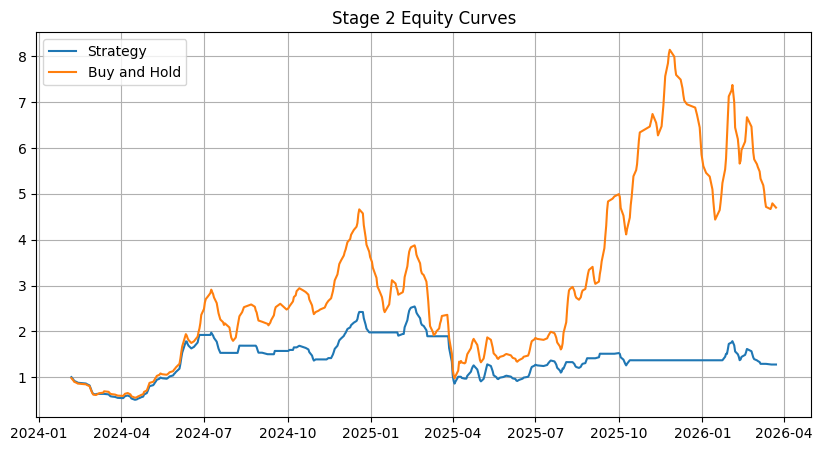

In [113]:
# Plot the Stage 2A strategy and buy-and-hold equity curves

plt.figure()
plt.plot(stage2_backtest["date"], stage2_backtest["strategy_equity"], label="Strategy")
plt.plot(stage2_backtest["date"], stage2_backtest["buy_hold_equity"], label="Buy and Hold")
plt.title("Stage 2 Equity Curves")
plt.legend()
plt.grid(True)
plt.show()

### What this stage does

In this stage, the selected best LSTM model is evaluated in a simple trading setting. The model’s classification predictions are converted into trading signals, and these signals are used to simulate a trading strategy over the test period. The resulting strategy performance is then compared against a buy-and-hold benchmark using measures such as total return, drawdown, and Sharpe ratio.

### Why this stage is included

This stage is included because predictive performance alone is not enough to judge whether the model is useful in practice. Even if the model shows some forecasting ability, that signal must still translate into meaningful financial performance once trading rules and transaction costs are taken into account.

### What is being tested

The main objective here is to test whether the best-performing LSTM configuration can generate economic value when its predictions are used in a trading strategy.

## Stage 2B — Confidence-Filtered Backtesting

## Confidence filter helpers

In [127]:
# Define helper functions for Stage 2B confidence-filtered backtesting

def apply_confidence_filter(pred_df: pd.DataFrame, threshold: float):
    # Only keep long signals when the model probability is above the confidence threshold
    out = pred_df.copy()
    out["signal"] = 0

    long_mask = out["y_prob"] >= threshold
    out.loc[long_mask, "signal"] = 1

    out["y_pred_filtered"] = out["signal"]
    return out


def run_confidence_filter_backtests(pred_df, full_data, thresholds, cost_bps=5):
    rows = []
    all_bt = {}

    for thr in thresholds:
        filtered = apply_confidence_filter(pred_df, threshold=thr)

        # Keep only the filtered prediction column and rename it as y_pred
        temp = filtered[["date", "y_true", "y_prob", "y_pred_filtered"]].copy()
        temp = temp.rename(columns={"y_pred_filtered": "y_pred"})

        bt = build_backtest_frame(temp, full_data, cost_bps=cost_bps)
        summary = summarize_backtest(bt)

        rows.append({
            "confidence_threshold": thr,
            "strategy_total_return": summary["strategy_total_return"],
            "strategy_max_drawdown": summary["strategy_max_drawdown"],
            "strategy_sharpe": summary["strategy_sharpe"],
            "num_trades_proxy": int(bt["position"].diff().abs().fillna(0).sum()),
        })
        all_bt[thr] = bt

    summary_df = pd.DataFrame(rows).sort_values(
        "strategy_total_return", ascending=False
    ).reset_index(drop=True)

    return summary_df, all_bt

## Run Stage 2.1 confidence filter

In [136]:
# Run Stage 2B confidence-filtered backtesting

# Define the confidence thresholds to test in Stage 2.1
confidence_thresholds = np.round(np.arange(0.50, 0.71, 0.02), 2)

stage21_summary_df, stage21_backtests = run_confidence_filter_backtests(
    pred_df=best_model_result["test_predictions"],
    full_data=best_model_result["data"],
    thresholds=confidence_thresholds,
    cost_bps=best_model_config["cost_bps"],
)

stage21_out = ensure_dir(ROOT_OUTPUT / "stage2_1_confidence_filter")
stage21_summary_df.to_csv(stage21_out / "confidence_filter_summary.csv", index=False)

best_conf_thr = stage21_summary_df.iloc[0]["confidence_threshold"]
best_conf_bt = stage21_backtests[best_conf_thr]
best_conf_bt.to_csv(stage21_out / "best_confidence_backtest.csv", index=False)

display(stage21_summary_df)
print("Best confidence threshold:", best_conf_thr)
display(best_conf_bt.head())

,confidence_threshold,strategy_total_return,strategy_max_drawdown,strategy_sharpe,num_trades_proxy
0,0.66,0.000000,0.000000,NaN,0
1,0.68,0.000000,0.000000,NaN,0
2,0.62,0.000000,0.000000,NaN,0
3,0.70,0.000000,0.000000,NaN,0
4,0.64,0.000000,0.000000,NaN,0
5,0.50,-0.080336,-0.632765,0.104145,46
6,0.54,-0.160235,-0.634416,-0.087872,30
7,0.52,-0.204089,-0.673319,-0.128712,44
8,0.60,-0.247828,-0.274496,-1.596184,8
9,0.56,-0.378218,-0.575491,-0.864128,36


Best confidence threshold: 0.66


,date,y_true,y_prob,y_pred,future_return,signal,position,transaction_cost,strategy_return,buy_hold_return,strategy_equity,buy_hold_equity
0,2024-02-06,0,0.444319,0,-0.021257,0,0.0,0.0,-0.0,-0.021257,1.0,0.978743
1,2024-02-07,0,0.509698,0,-0.026530,0,0.0,0.0,-0.0,-0.026530,1.0,0.952777
2,2024-02-08,0,0.511443,0,-0.022437,0,0.0,0.0,-0.0,-0.022437,1.0,0.931400
3,2024-02-09,0,0.527729,0,-0.034631,0,0.0,0.0,-0.0,-0.034631,1.0,0.899145
4,2024-02-12,0,0.534015,0,-0.029869,0,0.0,0.0,-0.0,-0.029869,1.0,0.872288


## What this stage does

In this stage, the best LSTM model’s predicted probabilities are filtered using a range of confidence thresholds. Instead of trading on every prediction, the strategy only enters trades when the model output is strong enough to pass the selected threshold. The notebook then backtests the strategy under each threshold and compares the resulting performance.

## Why this stage is included

This stage is included to test whether the model’s more confident predictions are more useful than its weaker predictions. If the model’s confidence scores are informative, then ignoring lower-confidence signals may improve trading performance by reducing noisy or less reliable trades.

## What is being tested

The main objective here is to determine whether applying a confidence filter can improve the economic usefulness of the model compared with trading on all predictions.

# Stage 3 — Multi-Stock Generalization

## Multi-stock helper

In [147]:
# Define helper functions for Stage 3 multi-stock generalization

def run_multistock_experiment(tickers, base_config):
    # Reuse the best model design across multiple stocks to test generalization
    rows = []
    all_results = {}

    for ticker in tickers:
        cfg = base_config.copy()
        cfg["ticker"] = ticker

        result = run_classification_stage(
            stage_name=f"stage3_{ticker}",
            config=cfg,
            use_technicals=True,
            clean_target=True,
            tune_threshold_on_val=True,
        )

        rows.append({
            "ticker": ticker,
            "val_auc": result["val_metrics"]["auc"],
            "val_balanced_accuracy": result["val_metrics"]["balanced_accuracy"],
            "test_auc": result["test_metrics"]["auc"],
            "test_balanced_accuracy": result["test_metrics"]["balanced_accuracy"],
            "test_accuracy": result["test_metrics"]["accuracy"],
            "threshold": result["threshold"],
        })

        all_results[ticker] = result

    summary_df = pd.DataFrame(rows).sort_values("test_auc", ascending=False).reset_index(drop=True)
    return summary_df, all_results

## Run Stage 3 multi-stock

In [151]:
# Run Stage 3 multi-stock generalization

# Define the list of stocks used for the generalization experiment
stage3_tickers = ["AAPL", "TSLA", "AMZN", "MSFT"]

stage3_summary_df, stage3_results = run_multistock_experiment(
    tickers=stage3_tickers,
    base_config=best_model_config,
)

stage3_out = ensure_dir(ROOT_OUTPUT / "stage3_multistock")
stage3_summary_df.to_csv(stage3_out / "multistock_summary.csv", index=False)

Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5559 - loss: 0.7144 - val_accuracy: 0.5398 - val_loss: 0.6993 - learning_rate: 3.0000e-04
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5657 - loss: 0.7015 - val_accuracy: 0.4747 - val_loss: 0.6999 - learning_rate: 3.0000e-04
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5582 - loss: 0.6964 - val_accuracy: 0.4771 - val_loss: 0.6994 - learning_rate: 3.0000e-04
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5559 - loss: 0.6937 - val_accuracy: 0.4795 - val_loss: 0.6992 - learning_rate: 3.0000e-04
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5629 - loss: 0.6880 - val_accuracy: 0.4675 - val_loss: 0.6988 - learning_rate: 3.0000e-04
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5735 - loss: 0.6851 - val_accuracy: 0.4651 - val_loss: 0.6988 - learning_rate: 3.0000e-04
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5787 -

,ticker,val_auc,val_balanced_accuracy,test_auc,test_balanced_accuracy,test_accuracy,threshold
0,AMZN,0.521114,0.544633,0.524298,0.529557,0.497608,0.52
1,MSFT,0.570871,0.558886,0.473287,0.483357,0.510417,0.44
2,TSLA,0.549893,0.550467,0.451865,0.491408,0.494553,0.53
3,AAPL,0.607016,0.594362,0.428019,0.446360,0.448193,0.50


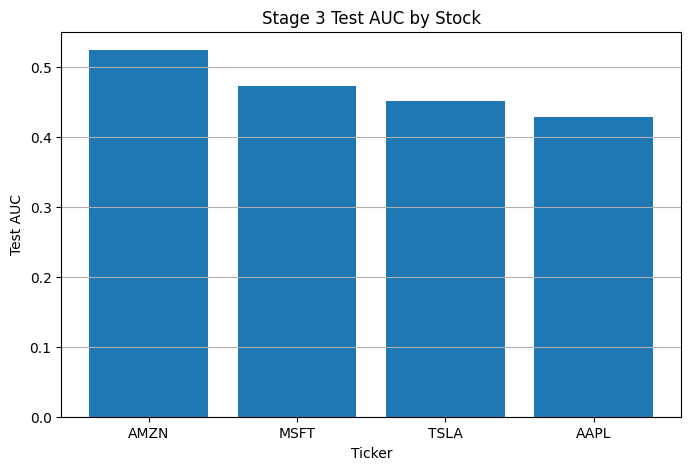

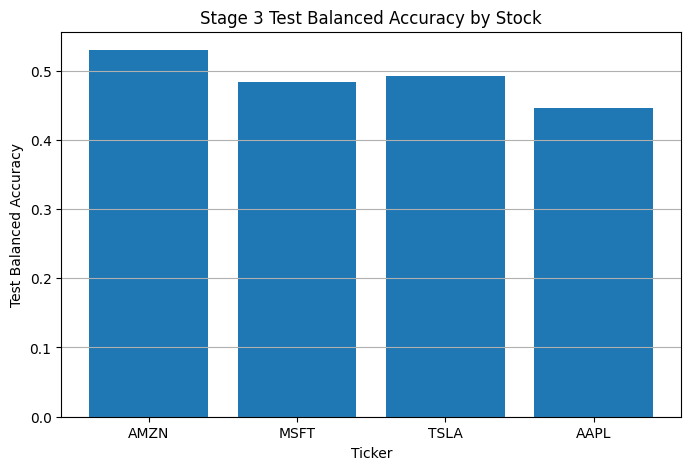

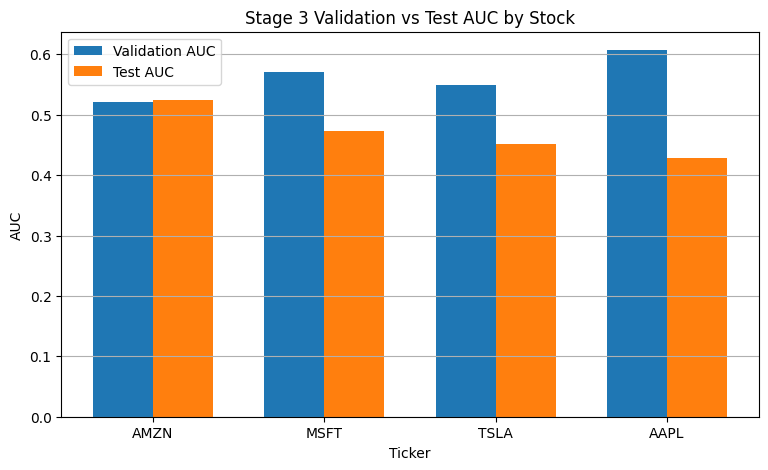

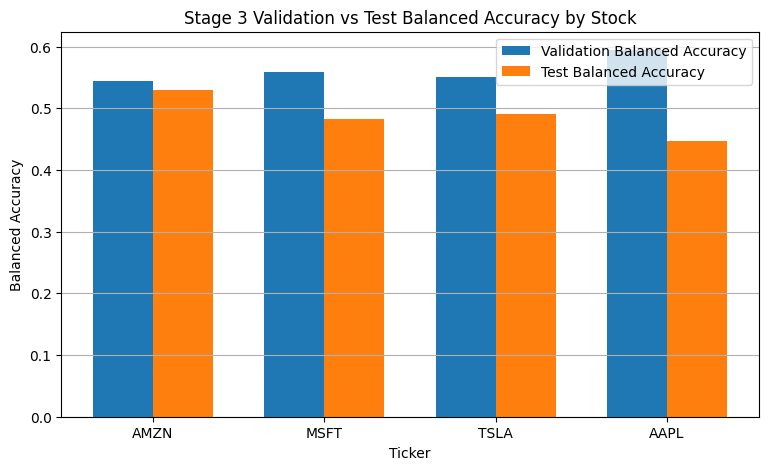

In [160]:
# Display Stage 3 summary results and comparison charts

# Show the full summary table for all stocks
# This table compares validation and test performance across the selected stocks
display(stage3_summary_df)

# Create a copy of the summary table for plotting
plot_df = stage3_summary_df.copy()

# Plot the test AUC for each stock
# AUC is one of the main metrics used to judge predictive signal quality
plt.figure(figsize=(8, 5))
plt.bar(plot_df["ticker"], plot_df["test_auc"])
plt.title("Stage 3 Test AUC by Stock")
plt.xlabel("Ticker")
plt.ylabel("Test AUC")
plt.grid(True, axis="y")
plt.show()

# Plot the test balanced accuracy for each stock
# Balanced accuracy is useful because it is less misleading than plain accuracy
plt.figure(figsize=(8, 5))
plt.bar(plot_df["ticker"], plot_df["test_balanced_accuracy"])
plt.title("Stage 3 Test Balanced Accuracy by Stock")
plt.xlabel("Ticker")
plt.ylabel("Test Balanced Accuracy")
plt.grid(True, axis="y")
plt.show()

# Plot validation AUC against test AUC for each stock
# This helps compare whether validation performance transferred to test performance
x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width / 2, plot_df["val_auc"], width, label="Validation AUC")
plt.bar(x + width / 2, plot_df["test_auc"], width, label="Test AUC")
plt.xticks(x, plot_df["ticker"])
plt.title("Stage 3 Validation vs Test AUC by Stock")
plt.xlabel("Ticker")
plt.ylabel("AUC")
plt.legend()
plt.grid(True, axis="y")
plt.show()

# Plot validation balanced accuracy against test balanced accuracy for each stock
# This helps assess whether classification performance remained stable out of sample
plt.figure(figsize=(9, 5))
plt.bar(x - width / 2, plot_df["val_balanced_accuracy"], width, label="Validation Balanced Accuracy")
plt.bar(x + width / 2, plot_df["test_balanced_accuracy"], width, label="Test Balanced Accuracy")
plt.xticks(x, plot_df["ticker"])
plt.title("Stage 3 Validation vs Test Balanced Accuracy by Stock")
plt.xlabel("Ticker")
plt.ylabel("Balanced Accuracy")
plt.legend()
plt.grid(True, axis="y")
plt.show()

## What this stage does

In this stage, the best-performing LSTM configuration selected earlier is applied to multiple stocks rather than only one. The same feature construction logic, target setup, and model design are reused across different equities so that performance can be compared in a consistent way. The results are then summarized using validation and test classification metrics for each stock.

## Why this stage is included

This stage is included to test whether the learned modelling approach is specific to one stock or whether it captures a small signal that is at least partially transferable across other equities. In other words, it checks whether the model has some degree of robustness beyond the original stock used in development.

## What is being tested

The main objective here is to evaluate the generalizability of the best LSTM framework across multiple stocks. In particular, this stage examines whether the model can maintain at least some predictive signal when applied to different equities, even if the performance remains weak or inconsistent.

# Stage 4 — Explainability and Insights

## Explainability helpers

In [164]:
# Define helper functions for Stage 4 explainability and insights

def evaluate_feature_permutation(
    result_dict,
    n_repeats: int = 1,
    random_seed: int = 42,
):
    # Estimate feature importance by measuring how much AUC drops after feature shuffling
    rng = np.random.default_rng(random_seed)

    pred_df = result_dict["test_predictions"].copy()
    data = result_dict["data"].copy()
    feature_cols = result_dict["feature_cols"]
    config = result_dict["config"]

    train_df, val_df, test_df = time_split(
        data,
        train_ratio=config["train_ratio"],
        val_ratio=config["val_ratio"],
    )

    X_train_df, y_train = split_X_y(train_df, feature_cols)
    X_val_df, y_val = split_X_y(val_df, feature_cols)
    X_test_df, y_test = split_X_y(test_df, feature_cols)

    X_train_s, X_val_s, X_test_s, scaler_X = fit_scale_features(X_train_df, X_val_df, X_test_df)

    X_train_seq, y_train_seq, _ = make_sequences(X_train_s, y_train.values, config["lookback"], train_df.index)
    X_val_seq, y_val_seq, _ = make_sequences(X_val_s, y_val.values, config["lookback"], val_df.index)
    X_test_seq, y_test_seq, _ = make_sequences(X_test_s, y_test.values, config["lookback"], test_df.index)

    model = result_dict["model"]
    # First measure the model performance before any feature is shuffled
    baseline_prob = model.predict(X_test_seq, verbose=0).ravel()
    baseline_auc = roc_auc_score(y_test_seq, baseline_prob)

    rows = []
    # Shuffle one feature at a time and measure the impact on performance
    for feat_idx, feat_name in enumerate(feature_cols):
        auc_scores = []

        for _ in range(n_repeats):
            X_perm = X_test_seq.copy()
            shuffled = X_perm[:, :, feat_idx].copy().reshape(-1)
            rng.shuffle(shuffled)
            X_perm[:, :, feat_idx] = shuffled.reshape(X_perm[:, :, feat_idx].shape)

            perm_prob = model.predict(X_perm, verbose=0).ravel()
            perm_auc = roc_auc_score(y_test_seq, perm_prob)
            auc_scores.append(perm_auc)

        mean_perm_auc = float(np.mean(auc_scores))
        rows.append({
            "feature": feat_name,
            "baseline_auc": float(baseline_auc),
            "permuted_auc": mean_perm_auc,
            "auc_drop": float(baseline_auc - mean_perm_auc),
        })

    imp_df = pd.DataFrame(rows).sort_values("auc_drop", ascending=False).reset_index(drop=True)
    return imp_df


def get_prediction_buckets(pred_df: pd.DataFrame, top_n: int = 10):
    # Group predictions into confident correct, confident wrong, and borderline cases
    out = pred_df.copy()
    out["correct"] = (out["y_true"] == out["y_pred"]).astype(int)
    out["distance_from_05"] = (out["y_prob"] - 0.5).abs()

    confident_correct = out[out["correct"] == 1].sort_values("distance_from_05", ascending=False).head(top_n)
    confident_wrong = out[out["correct"] == 0].sort_values("distance_from_05", ascending=False).head(top_n)
    borderline = out.sort_values("distance_from_05", ascending=True).head(top_n)

    return confident_correct, confident_wrong, borderline

## Run Stage 4 explainability

In [176]:
# Run Stage 4 explainability and save the key outputs

stage4_out = ensure_dir(ROOT_OUTPUT / "stage4_explainability")

# Run feature importance and prediction case analysis for explainability
perm_importance_df = evaluate_feature_permutation(
    result_dict=best_model_result,
    n_repeats=1,
    random_seed=42,
)

confident_correct_df, confident_wrong_df, borderline_df = get_prediction_buckets(
    best_model_result["test_predictions"],
    top_n=10,
)

perm_importance_df.to_csv(stage4_out / "permutation_importance.csv", index=False)
confident_correct_df.to_csv(stage4_out / "confident_correct.csv", index=False)
confident_wrong_df.to_csv(stage4_out / "confident_wrong.csv", index=False)
borderline_df.to_csv(stage4_out / "borderline_predictions.csv", index=False)

# Display Stage 4 explainability outputs

# Show the top permutation importance results
# A larger AUC drop means the feature is more important to the model
display(perm_importance_df.head(12))

# Show the most confident correct predictions
# These are cases where the model was strongly confident and also correct
display(confident_correct_df)

# Show the most confident wrong predictions
# These are useful failure cases because the model was confident but still wrong
display(confident_wrong_df)

# Show the borderline predictions
# These are cases where the predicted probability was very close to 0.5
display(borderline_df)

,feature,baseline_auc,permuted_auc,auc_drop
0,EMA10,0.455343,0.434844,0.020499
1,Close,0.455343,0.435501,0.019842
2,MACDsig,0.455343,0.444882,0.010461
3,Low,0.455343,0.447345,0.007998
4,MA20,0.455343,0.448002,0.007341
5,RSI14,0.455343,0.448400,0.006942
6,HL_Spread,0.455343,0.448494,0.006849
7,EMA_Cross,0.455343,0.448893,0.006450
8,BB_Width,0.455343,0.450793,0.004550
9,ATR14,0.455343,0.451942,0.003401


,date,y_true,y_prob,y_pred,correct,distance_from_05
176,2025-01-10,0,0.378891,0,1,0.121109
372,2026-01-05,0,0.380154,0,1,0.119846
312,2025-09-04,0,0.380642,0,1,0.119358
179,2025-01-15,0,0.382142,0,1,0.117858
175,2025-01-08,0,0.383001,0,1,0.116999
211,2025-03-11,0,0.383977,0,1,0.116023
178,2025-01-14,0,0.384241,0,1,0.115759
374,2026-01-12,0,0.385286,0,1,0.114714
180,2025-01-16,0,0.385446,0,1,0.114554
177,2025-01-13,0,0.386703,0,1,0.113297


,date,y_true,y_prob,y_pred,correct,distance_from_05
339,2025-10-21,1,0.372056,0,0,0.127944
119,2024-09-17,1,0.377908,0,0,0.122092
212,2025-03-13,1,0.378564,0,0,0.121436
293,2025-08-05,1,0.385455,0,0,0.114545
316,2025-09-11,1,0.385796,0,0,0.114204
199,2025-02-20,0,0.613955,1,0,0.113955
341,2025-10-23,1,0.386112,0,0,0.113888
337,2025-10-17,1,0.387760,0,0,0.112240
338,2025-10-20,1,0.388186,0,0,0.111814
200,2025-02-21,0,0.611655,1,0,0.111655


,date,y_true,y_prob,y_pred,correct,distance_from_05
286,2025-07-25,0,0.500907,1,0,0.000907
21,2024-03-19,0,0.501374,1,0,0.001374
287,2025-07-28,0,0.498567,1,0,0.001433
402,2026-02-27,0,0.501465,1,0,0.001465
265,2025-06-11,0,0.497687,1,0,0.002313
44,2024-05-02,1,0.502772,1,1,0.002772
285,2025-07-24,0,0.502802,1,0,0.002802
33,2024-04-15,0,0.496691,1,0,0.003309
288,2025-07-29,0,0.496418,1,0,0.003582
6,2024-02-22,0,0.495232,1,0,0.004768


## Stage 4 plots

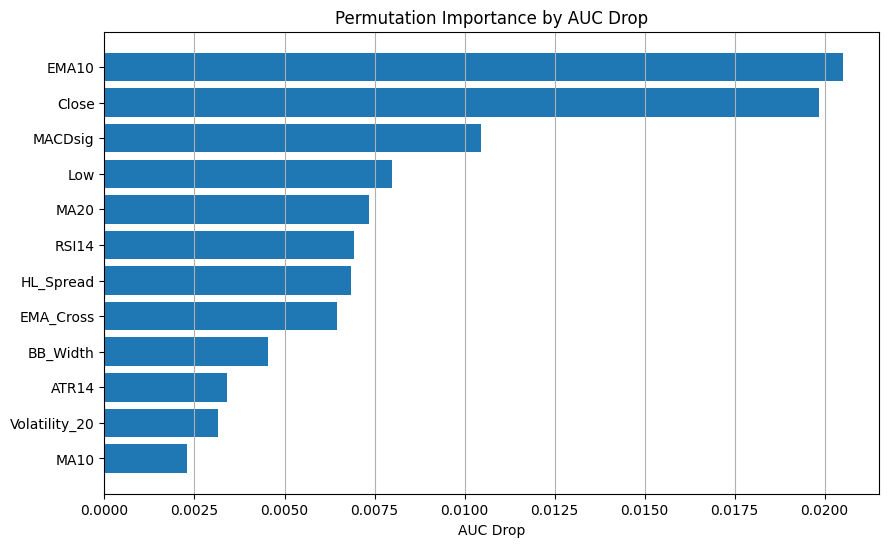

In [172]:
# Plot the top permutation importance features

top_k = 12
plot_df = perm_importance_df.head(top_k).sort_values("auc_drop", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"], plot_df["auc_drop"])
plt.title("Permutation Importance by AUC Drop")
plt.xlabel("AUC Drop")
plt.grid(True, axis="x")
plt.show()

## What this stage does

This stage explains the behaviour of the best LSTM model using feature importance and selected prediction examples.

## Why this stage is included

This stage is included to understand which features the model relies on and where it tends to make strong correct or incorrect predictions.

## What is being tested

The main objective here is to interpret the model’s behaviour and assess whether its learned patterns are sensible and stable.